## Exploratory Models: Using Experimental Data

In [1]:
"""Importing all required libaries"""
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from rdkit import Chem
from rdkit.Chem import Descriptors, rdFingerprintGenerator
from rdkit import RDLogger
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import shap
import zipfile

c:\Users\amylc\anaconda3\envs\aqsoldb3-11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Merging and Preparation

In [ ]:
# 1. Load cleaned AqSolDBc
df = pd.read_csv('path/to/AqSolDBc')
df = df.dropna(subset=["SMILES", "ExperimentalLogS"]).drop_duplicates(subset=['SMILES'])
df = df[(df['ExperimentalLogS'] > -12) & (df['ExperimentalLogS'] < 2)]

# 2. Load Al Ibrahim data from ZIP
zip_path = "path/to/AlIbrahim data"
with zipfile.ZipFile(zip_path) as z:
    tmp = pd.read_csv(z.open("Tmp_DB.csv"))
    hfus = pd.read_csv(z.open("dHfus_DB.csv"))

# 3. Canonicalize SMILES
print("Canonicalizing SMILES across datasets. This may take a moment...")
def canon(smiles):
    try:
        return Chem.MolToSmiles(Chem.MolFromSmiles(smiles))
    except:
        return None

df["canon_smiles"] = df["SMILES"].apply(canon)
tmp["canon_smiles"] = tmp["smiles"].apply(canon)
hfus["canon_smiles"] = hfus["smiles"].apply(canon)

# 4. Clean and rename thermo columns
# Helper function to convert comma-separated strings into a single average float
def string_to_avg(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        try:
            # Clean string, split by comma, convert to floats, and take the mean
            clean_str = val.replace('[', '').replace(']', '')
            nums = [float(x.strip()) for x in clean_str.split(',')]
            return np.mean(nums)
        except:
            return np.nan
    return np.nan

# TMP: melting point
tmp = tmp.rename(columns={"Tm[K]": "melting_point"})
tmp['melting_point'] = tmp['melting_point'].apply(string_to_avg)

# HFUS: fusion enthalpy (convert from kcal/mol to kJ/mol)
hfus['dHfus [kcal/mol]'] = hfus['dHfus [kcal/mol]'].apply(string_to_avg)
hfus["fusion_enthalpy"] = hfus["dHfus [kcal/mol]"] * 4.184

# 5. Merge datasets
merged = (
    df
    .merge(tmp[["canon_smiles", "melting_point"]], on="canon_smiles", how="left")
    .merge(hfus[["canon_smiles", "fusion_enthalpy"]], on="canon_smiles", how="left")
)

# Calculate LogP and MW for exploratory graphs
print("Calculating LogP and MW for exploration...")
merged['MolLogP'] = merged['SMILES'].apply(lambda x: Descriptors.MolLogP(Chem.MolFromSmiles(x)) if Chem.MolFromSmiles(x) else np.nan)
merged['MolWt'] = merged['SMILES'].apply(lambda x: Descriptors.MolWt(Chem.MolFromSmiles(x)) if Chem.MolFromSmiles(x) else np.nan)

# 6. Create Dataset 1 (Enthalpy + MP)
df_fusion = merged.dropna(subset=["melting_point", "fusion_enthalpy"]).copy()
df_fusion = merged.dropna(subset=["melting_point", "fusion_enthalpy"]).drop_duplicates(subset=['canon_smiles']).copy()

# 7. Create Dataset 2 (MP Only)
df_mp = merged.dropna(subset=["melting_point"]).copy()
df_mp = merged.dropna(subset=["melting_point"]).drop_duplicates(subset=['canon_smiles']).copy()

print(f"Dataset 1 (MP + Hfus) molecules: {len(df_fusion)}")
print(f"Dataset 2 (MP Only) molecules: {len(df_mp)}")

Canonicalizing SMILES across datasets. This may take a moment...


[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not removing hydrogen atom without neighbors
[11:36:44] WARNING: not r

Calculating LogP and MW for exploration...


[11:38:00] WARNING: not removing hydrogen atom without neighbors
[11:38:00] WARNING: not removing hydrogen atom without neighbors
[11:38:00] WARNING: not removing hydrogen atom without neighbors
[11:38:00] WARNING: not removing hydrogen atom without neighbors
[11:38:00] WARNING: not removing hydrogen atom without neighbors
[11:38:00] WARNING: not removing hydrogen atom without neighbors
[11:38:00] WARNING: not removing hydrogen atom without neighbors
[11:38:00] WARNING: not removing hydrogen atom without neighbors
[11:38:01] WARNING: not removing hydrogen atom without neighbors
[11:38:01] WARNING: not removing hydrogen atom without neighbors
[11:38:01] WARNING: not removing hydrogen atom without neighbors
[11:38:01] WARNING: not removing hydrogen atom without neighbors
[11:38:01] WARNING: not removing hydrogen atom without neighbors
[11:38:01] WARNING: not removing hydrogen atom without neighbors
[11:38:01] WARNING: not removing hydrogen atom without neighbors
[11:38:01] WARNING: not r

Dataset 1 (MP + Hfus) molecules: 949
Dataset 2 (MP Only) molecules: 4186


[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not removing hydrogen atom without neighbors
[11:38:06] WARNING: not r

### Plotting Functions

In [7]:
def plot_histogram(y, xlabel, color):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(7, 5))
    
    # Base histogram
    sns.histplot(y, kde=False, stat='density', bins=30, color=color, alpha=0.6)
    
    mean = np.mean(y)
    median = np.median(y)
    std = np.std(y)
    n = len(y)
    
    # Normal distribution overlay
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean, std)
    plt.plot(x, p, color=color, linewidth=2, label='Normal Distribution')

    # Lines for mean and median
    plt.axvline(mean, color='black', linestyle='--', linewidth=1.2, label=f"Mean = {mean:.2f}")
    plt.axvline(median, color='green', linestyle=':', linewidth=1.2, label=f"Median = {median:.2f}")

    # Set specific labels
    if 'Solubility' in xlabel or 'LogS' in xlabel:
        plt.xlabel('Solubility, LogS')
        plt.ylabel('Normalised frequency')
    else:
        plt.xlabel(xlabel)
        plt.ylabel('Density')

    # Annotate with text box
    textstr = '\n'.join((
        f'n = {n}',
        f'Mean = {mean:.3f}',
        f'Median = {median:.3f}',
        f'SD = {std:.3f}'
    ))
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.98, 0.95, textstr, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)

    plt.legend()
    plt.show()

def plot_actual_vs_predicted(y_true, y_pred, color, title_metrics):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, alpha=0.5, color=color, edgecolor='white')
    
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect Prediction')
    
    plt.xlabel('Actual Solubility, LogS')
    plt.ylabel('Predicted Solubility, LogS')
    
    plt.scatter([], [], alpha=0, label=title_metrics)
    plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    plt.show()

### Dataset One: MP+Fusion Graphs

--- Data Exploration: Dataset 1 (MP + Enthalpy of Fusion) ---


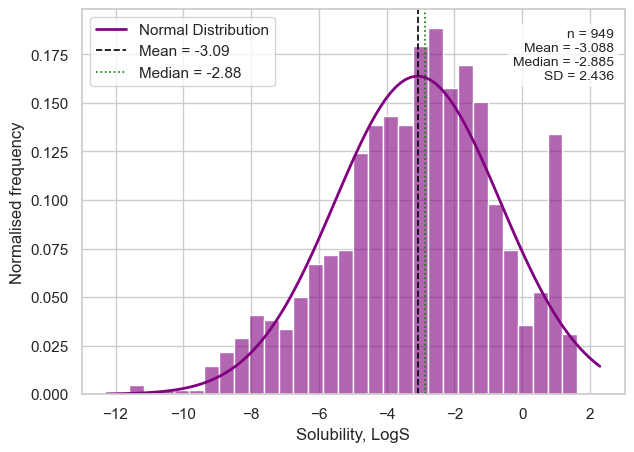

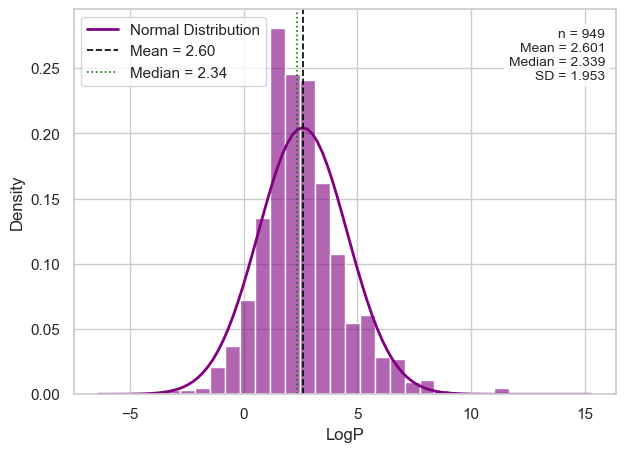

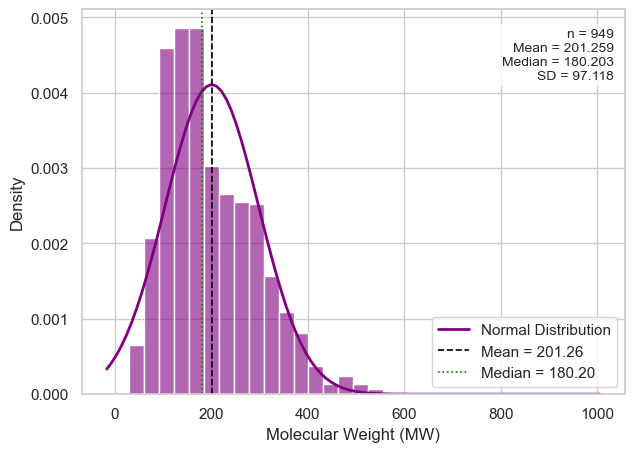

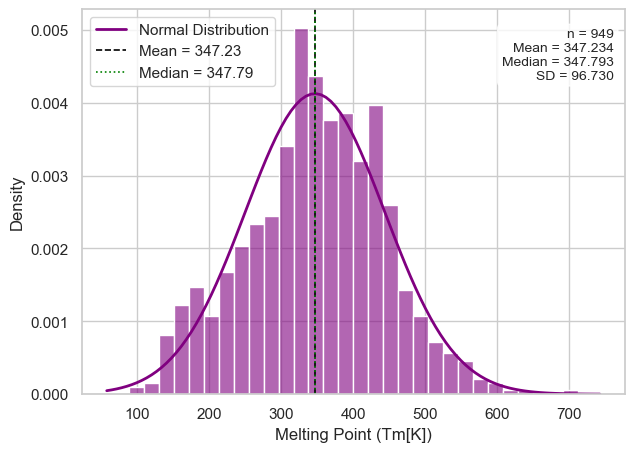

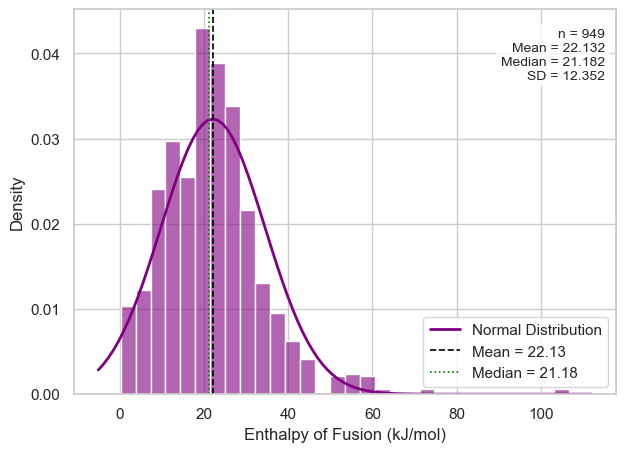

In [8]:
print("--- Data Exploration: Dataset 1 (MP + Enthalpy of Fusion) ---")
plot_histogram(df_fusion['ExperimentalLogS'], 'Solubility, LogS', 'purple')
plot_histogram(df_fusion['MolLogP'], 'LogP', 'purple')
plot_histogram(df_fusion['MolWt'], 'Molecular Weight (MW)', 'purple')
plot_histogram(df_fusion['melting_point'], 'Melting Point (Tm[K])', 'purple')
plot_histogram(df_fusion['fusion_enthalpy'], 'Enthalpy of Fusion (kJ/mol)', 'purple')

### DataSet 2: MP Only Graphs

--- Data Exploration: Dataset 2 (MP Only) ---


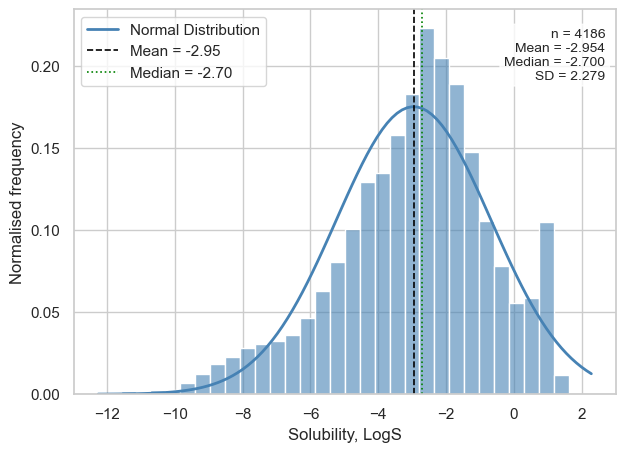

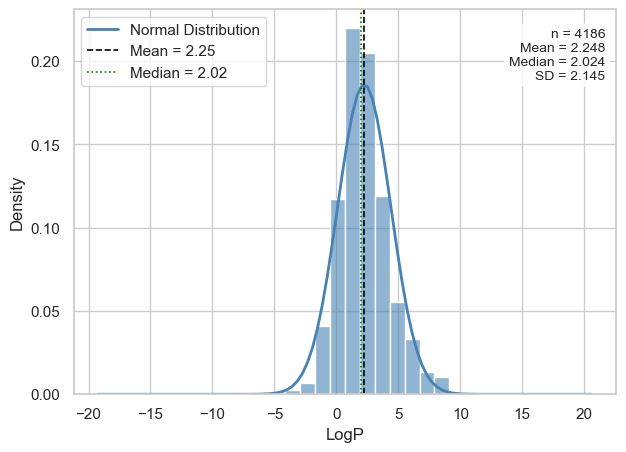

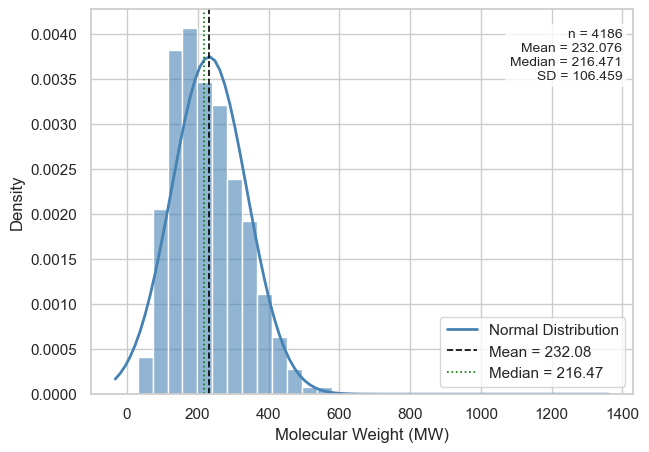

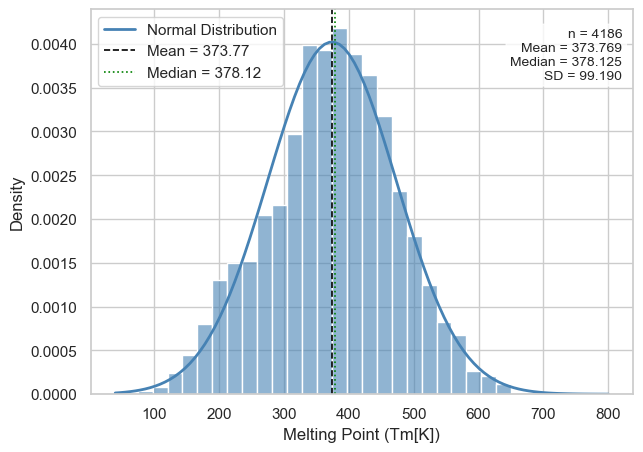

In [9]:
print("--- Data Exploration: Dataset 2 (MP Only) ---")
plot_histogram(df_mp['ExperimentalLogS'], 'Solubility, LogS', 'steelblue')
plot_histogram(df_mp['MolLogP'], 'LogP', 'steelblue')
plot_histogram(df_mp['MolWt'], 'Molecular Weight (MW)', 'steelblue')
plot_histogram(df_mp['melting_point'], 'Melting Point (Tm[K])', 'steelblue')

### Featurisation and Cleaning Function

In [10]:
def featurize_and_clean(df, extra_features):
    X_smiles = df['SMILES'].values
    y = df['ExperimentalLogS'].values
    
    fps, desc_list, valid_indices = [], [], []
    desc_names = [n[0] for n in Descriptors._descList]
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    
    print("Generating RDKit Descriptors and Morgan Fingerprints...")
    for i, smiles in enumerate(tqdm(X_smiles)):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            fps.append(list(mfpgen.GetFingerprint(mol)))
            desc_list.append([f(mol) for _, f in Descriptors._descList])
            valid_indices.append(i)
            
    df_fp = pd.DataFrame(fps, columns=[f'MF_{i}' for i in range(2048)])
    df_desc = pd.DataFrame(desc_list, columns=desc_names)
    
    # Extract extra thermodynamic features for valid molecules
    extra_df = df.iloc[valid_indices][extra_features].reset_index(drop=True)
    
    # Combine everything
    X = pd.concat([df_desc, df_fp, extra_df], axis=1)
    y_valid = y[valid_indices]
    
    X.columns = X.columns.str.replace(r'[\[\]<>]', '_', regex=True)
    
    X = X.replace([np.inf, -np.inf], np.nan)
    
    print("\nApplying NaN Logic...")
    if 'Ipc' in X.columns:
        X = X.drop(columns=['Ipc'])
        print("- Dropped 'Ipc'")
        
    threshold = 0.10 * len(X)
    nan_counts = X.isna().sum()
    cols_to_drop = nan_counts[nan_counts > threshold].index.tolist()
    if cols_to_drop:
        X = X.drop(columns=cols_to_drop)
        print(f"- Dropped {len(cols_to_drop)} columns with > 10% NaNs")
        
    combined = X.copy()
    combined['TARGET'] = y_valid
    initial_len = len(combined)
    combined = combined.dropna()
    print(f"- Dropped {initial_len - len(combined)} rows with remaining NaNs")
    
    return combined.drop(columns=['TARGET']), combined['TARGET'].values

### Model One: MP and Fusion

--- Training Model 1: MP + Hfus ---
Generating RDKit Descriptors and Morgan Fingerprints...


100%|██████████| 949/949 [00:06<00:00, 136.95it/s]



Applying NaN Logic...
- Dropped 'Ipc'
- Dropped 0 rows with remaining NaNs
XGBoost (MP+Hfus)
R2 = 0.925
RMSE = 0.703
MAE = 0.497
% w/in 0.7 = 77.9%
% w/in 1.0 = 90.5%


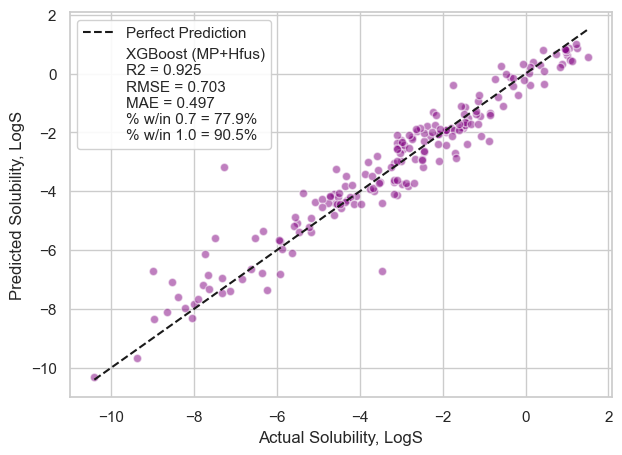


Generating SHAP Beeswarm Plot...


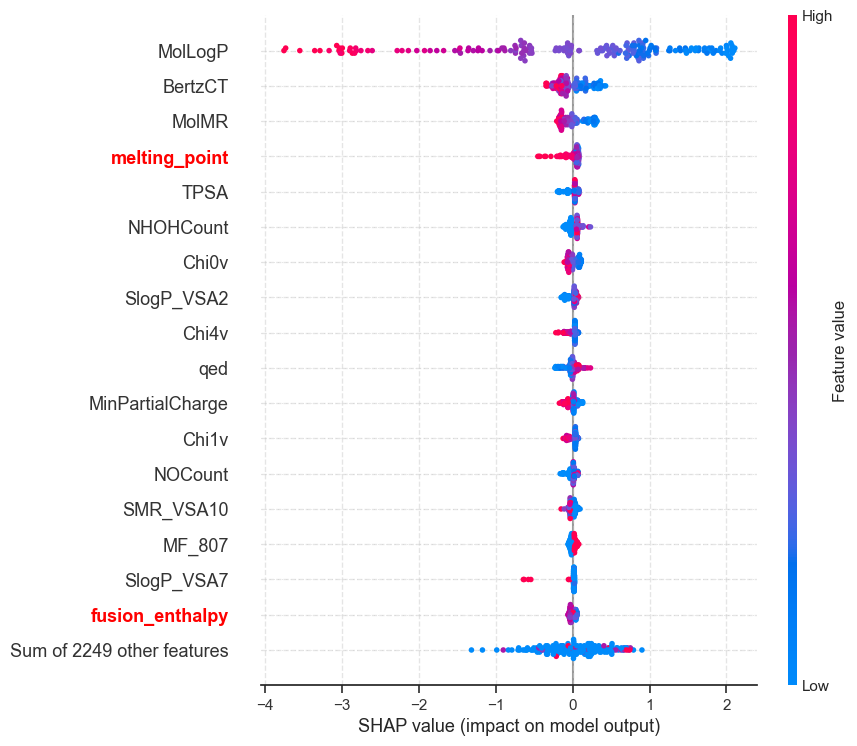

In [12]:
print("--- Training Model 1: MP + Hfus ---")
X1, y1 = featurize_and_clean(df_fusion, extra_features=['melting_point', 'fusion_enthalpy'])

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Model configuration to minimise overfitting
xgb1 = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb1.fit(X_train1, y_train1)
y_pred1 = xgb1.predict(X_test1)

# Metrics
r2_1 = r2_score(y_test1, y_pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test1, y_pred1))
mae_1 = mean_absolute_error(y_test1, y_pred1)
diff_1 = np.abs(y_test1 - y_pred1)
pct_07_1 = (diff_1 <= 0.7).mean() * 100
pct_10_1 = (diff_1 <= 1.0).mean() * 100

metrics_str1 = f"XGBoost (MP+Hfus)\nR2 = {r2_1:.3f}\nRMSE = {rmse_1:.3f}\nMAE = {mae_1:.3f}\n% w/in 0.7 = {pct_07_1:.1f}%\n% w/in 1.0 = {pct_10_1:.1f}%"
print(metrics_str1)
plot_actual_vs_predicted(y_test1, y_pred1, 'purple', metrics_str1)

# SHAP Graph
print("\nGenerating SHAP Beeswarm Plot...")
sns.set_theme(style="ticks")
explainer1 = shap.Explainer(xgb1, X_train1)
shap_values1 = explainer1(X_test1)

shap.plots.beeswarm(shap_values1, max_display=18, show=False)
fig = plt.gcf()
ax = plt.gca()

# Highlight melting_point and fusion_enthalpy labels on the y-axis
for tick in ax.get_yticklabels():
    if tick.get_text() in ['melting_point', 'fusion_enthalpy']:
        tick.set_color('red')
        tick.set_fontweight('bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Model Two: MP Only

--- Training Model 2: MP Only ---
Generating RDKit Descriptors and Morgan Fingerprints...


 13%|█▎        | 531/4186 [00:03<00:22, 160.49it/s][11:40:22] WARNING: not removing hydrogen atom without neighbors
[11:40:22] WARNING: not removing hydrogen atom without neighbors
100%|██████████| 4186/4186 [00:37<00:00, 110.90it/s]



Applying NaN Logic...
- Dropped 'Ipc'
- Dropped 0 rows with remaining NaNs
XGBoost (MP Only)
R2 = 0.887
RMSE = 0.730
MAE = 0.512
% w/in 0.7 = 77.3%
% w/in 1.0 = 87.4%


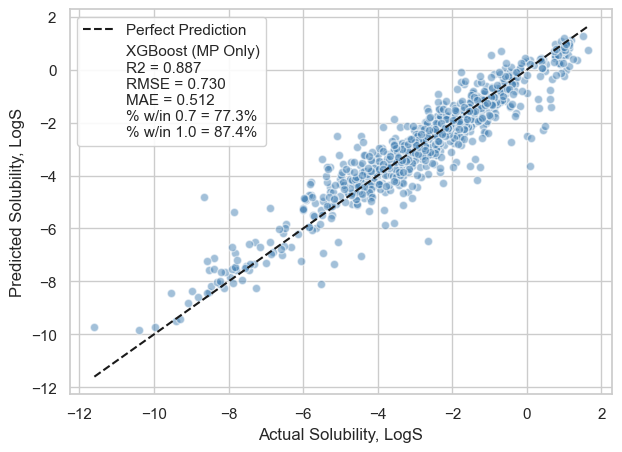


Generating SHAP Beeswarm Plot...


 94%|=================== | 787/838 [00:15<00:00]       

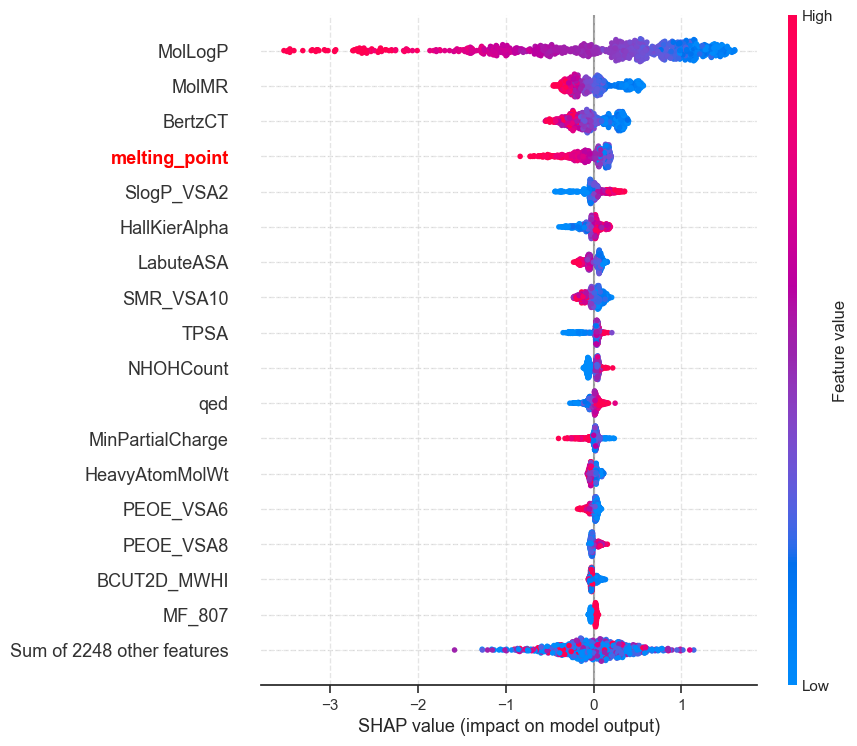

In [14]:
print("--- Training Model 2: MP Only ---")
X2, y2 = featurize_and_clean(df_mp, extra_features=['melting_point'])

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Original hyperparameter configuration
xgb2 = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42, 
    n_jobs=-1
)
xgb2.fit(X_train2, y_train2)
y_pred2 = xgb2.predict(X_test2)

# Metrics
r2_2 = r2_score(y_test2, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test2, y_pred2))
mae_2 = mean_absolute_error(y_test2, y_pred2)
diff_2 = np.abs(y_test2 - y_pred2)
pct_07_2 = (diff_2 <= 0.7).mean() * 100
pct_10_2 = (diff_2 <= 1.0).mean() * 100

metrics_str2 = f"XGBoost (MP Only)\nR2 = {r2_2:.3f}\nRMSE = {rmse_2:.3f}\nMAE = {mae_2:.3f}\n% w/in 0.7 = {pct_07_2:.1f}%\n% w/in 1.0 = {pct_10_2:.1f}%"
print(metrics_str2)
plot_actual_vs_predicted(y_test2, y_pred2, 'steelblue', metrics_str2)

# SHAP Graph
print("\nGenerating SHAP Beeswarm Plot...")
sns.set_theme(style="ticks")
explainer2 = shap.Explainer(xgb2, X_train2)
shap_values2 = explainer2(X_test2)

shap.plots.beeswarm(shap_values2, max_display=18, show=False)
fig2 = plt.gcf()
ax2 = plt.gca()

# Highlight melting_point label on the y-axis
for tick in ax2.get_yticklabels():
    if tick.get_text() == 'melting_point':
        tick.set_color('red')
        tick.set_fontweight('bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()